# Lidar autoencoder - harom architektura osszehasonlitasa

Mindharom modell ugyanabbol a nyers CARLA pontfelhobol indul, de MAS UTON
jut el a latensig. A latens megy majd az RL agent observationjebe.

| modell | mit lat a halo | loss | latens |
|---|---|---|---|
| `bev_ae` | madartavlati (BEV) pszeudo-kep | MSE | 128 |
| `graph_ae` | range image + dinamikus graf | L1 | 128 |
| `point_mae` | nyers pontok, patch-ekre bontva | Chamfer | 128 |

Mindharom **128 dimenzios latenst** ad, ugyanugy, mint a kamera modellek - igy
osszehasonlithatok, es barmelyik kozvetlenul beköthetö az RL observationbe.

**Miert mas a loss mindharomnal**

Nem szeszely: mindegyik a sajat reprezentaciojahoz illot hasznalja.
A `bev_ae` es a `graph_ae` RACSOT rekonstrual (rogzitett cellakkal), ott a
kepekre valo MSE/L1 a termeszetes. A `point_mae` viszont RENDEZETLEN
pontfelhot - ott az MSE az i-edik josolt pontot az i-edik valodihoz
parositana, pedig a pontfelhoben nincs sorrend.

Ezt kimertuk: egy teljes MSE-s futas (30 epoch) utan a modell Chamferrel
merve **10.51**-et adott, a Chamferrel tanitott **2.51** helyett - **4x
rosszabb geometria**. A halo a pontok SORRENDJET probalta tanulni a
geometria helyett.

> A nyers loss-szamokat ezert NEM hasonlitjuk ossze egymassal - mas celt,
> mas mertekegysegben mernek. A kozos merce a 7. szekcioban van
> (latens simasag, halott dimenziok), az mindharomra ugyanazt jelenti.

**Miert nem egy kaptafa mind a harom**

A kamera notebookban mindharom modell ugyanazt a 160x80-as kepet kapta, csak
a halo felepitese kulonbozott. Itt maskepp van: a pontfelho **rendezetlen** -
nincs "elso pont", es framenkent mas a darabszam (4753-14380). Mindharom
modell mas trukkel csinal ebbol valamit, amivel egy halo dolgozni tud:

- `bev_ae` - fentrol nezve racsra teriti, es kepkent kezeli
- `graph_ae` - a szenzor sajat geometriaja szerint range image-be teriti
- `point_mae` - meghagyja pontfelhonek, es patch-ekre bontja (FPS + kNN)

## Hardver: RTX 4080 SUPER (16 GB) + 128 GB RAM

**Adat: minden bekerul.** Mind az 54326 frame a RAM-ban. Ket reprezentacio,
egyetlen beolvasasbol:

- `clouds` (54326, 8192, 3) float32 = **5.3 GB** - a `bev_ae` es a `point_mae`
- `ranges` (54326, 1, 64, 1024) float16 = **7.1 GB** - a `graph_ae`, a
  **TELJES nyers felhobol** szamolva, tehat ott 0 pontot dobunk el

Osszesen 12.4 GB a 128-bol. Train/val vagas utan **46178 train** + **8148 val**.

**Batch-meretek** - a kartyan MERVE:

| modell | batch | csucs VRAM | sebesseg | epoch | szuk keresztmetszet |
|---|---|---|---|---|---|
| `bev_ae` | 32 | 6.8 GB | 281 frame/s | 2.7 perc | a **voxelizalas** (az ido 84%-a) |
| `graph_ae` | 8 | 8.1 GB | 29 frame/s | 26.5 perc | a **graf-retegek** (batch-fuggetlen) |
| `point_mae` | 64 | 5.3 GB | 1188 frame/s | 0.6 perc | a halo; 64 folott telitodik |

**Futasi sorrend: `bev_ae` -> `graph_ae` -> `point_mae`.** A `point_mae` van a
vegen, mert annak az architekturajat kulon kimertuk (lasd a 6. szekciot), es
igy a masik ketto mar lementette a checkpointjat, mire oda erunk.

**Varhato futasido 30 epochra:** `bev_ae` ~1.3 ora, `graph_ae` ~13 ora,
`point_mae` ~20 perc. Az early stopping (patience=5) barmelyiket leallithatja
hamarabb.

**A notebook felepitese**

1. Modulok betoltese
2. Adatok betoltese
3. Kozos tanito fuggvenyek
4. `bev_ae` tanitasa + gorbek
5. `graph_ae` tanitasa + gorbek
6. `point_mae` tanitasa + gorbek
7. **Osszehasonlitas** azonos frameken

Minden modell a sajat `lidar/<nev>.ckpt` fajljaba mentodik, es minden tanitas
utan felszabadul a VRAM (az adat a RAM-ban marad).

## 1. Modulok betoltese

In [23]:
import gc
import glob
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from lidar.point_mae import PointMAE
from lidar.bev_ae import BEVConvAE
from lidar.graph_ae import LidarAE, DDCONFIG, points_to_range_image

DATA_DIR = "dataset/lidar"
LATENT_DIM = 128          # a point_mae-nek es a bev_ae-nek ugyanaz
EPOCHS = 30
N_FRAMES = None           # None = mindent betoltunk

N_POINTS = 8192

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

torch.backends.cudnn.benchmark = True

print(DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
if torch.cuda.is_available():
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {total:.1f} GB")

cuda NVIDIA GeForce RTX 4080 SUPER
VRAM: 16.7 GB


In [24]:
def free_vram(*objects):
    """Modellek/tenzorok eldobasa a GPU-rol es a VRAM cache uritese.

    MIERT KELL: harom modellt tanitunk egymas utan. A PyTorch nem adja
    vissza magatol a memoriat az operacios rendszernek - a cache-ben tartja
    ujrahasznositasra. Ha nem uritjuk, a masodik/harmadik tanitas
    'CUDA out of memory'-val elszall, mert az elozo modell meg fogja a helyet.

    FIGYELEM: ez CSAK a 16 GB VRAM-ot takaritja, a sima RAM-ot nem. A teljes
    `clouds` tenzor (2.7 GB) vegig a rendszermemoriaban marad, batchenkent
    masoljuk at a GPU-ra - oda soha nem kerul be az egesz adat.
    """
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def vram():
    """Aktualis GPU memoriahasznalat GB-ban (a 16 GB-bol)."""
    if not torch.cuda.is_available():
        return "n/a"
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return (f"{torch.cuda.memory_allocated() / 1e9:.2f} GB foglalt / "
            f"{torch.cuda.memory_reserved() / 1e9:.2f} GB fenntartva / "
            f"{total:.1f} GB osszes")


print("indulaskor:", vram())

indulaskor: 0.52 GB foglalt / 10.87 GB fenntartva / 16.7 GB osszes


## 2. Adatok betoltese

A `dataset/lidar/` mappa `.npy` fajljai, mindegyik egy `(N, 3)` float32 tomb
(XYZ, meterben). A framek 20 Hz-cel, idorendben keszultek - ezert **keverni
kell** oket, kulonben egy batch ugyanannak a par masodpercnek a majdnem
azonos felhoibol allna, es a gradiens torzitana.

**A teljes adat bekerul.** Mind az 54326 frame: 8192 ponttal, float32-ben ez
**5.3 GB**, ami a gep 128 GB RAM-jahoz kepest semmi. Nincs `N_FRAMES` korlat.

### Hany pontot tartsunk meg framenkent?

A halok fix alaku tenzort varnak, a nyers felhokben viszont framenkent mas a
pontok szama: **4753-14380**, median **10664**. Valasztani kell egy szamot, es
ez a valasztas tenyleges adatvesztes - erdemes tudni, mennyi.

1500 frame-en merve:

| `N_POINTS` | megtartott pont | frame, ami duplikal | atlag duplikatum |
|---|---|---|---|
| 4096 | **38%** | 0% | 0 |
| **8192** | **77%** | 7% | 611 |
| 12288 | 99% | 84% | 2097 |

**8192-t hasznalunk.** A kezenfekvo 4096 a *legkisebb* frame-hez igazodna
(hogy soha ne kelljen pontot duplikalni), de ezzel a pontok **62%-at
eldobna**. A duplikalas nem nagy ar: a halo egy ismetlodo pontot lat, nem
kitalalt geometriat. Az viszont valodi veszteseg, ha a ritkitas a tavoli, kis
objektumokat tunteti el - a lidar sugarai tavolodva legyezoszeruen nyilnak,
ezert egy 40 m-re levo auto eleve keves pontot kap, es a ritkitasnal az esik
ki eloszor. Az RL-nek (dinamikus akadalyelkerules) pont azok kellenek.

12288 folott mar a framek 84%-a duplikalna, tehat nagyreszt ismetlest adnank
valodi tobblet helyett.

**A `graph_ae`-n latszik a legjobban**, mennyit szamit - a 64x1024-es range
image kitoltottsege:

| bemenet | kitoltott cella |
|---|---|
| `N_POINTS=4096` | 6.2% |
| `N_POINTS=8192` | **11.8%** |
| teljes felho | 15.8% |

4096-nal a modell a sajat kepenek tobb mint a felet feleslegesen uresnek
latta, pusztan a mintavetel miatt.

> **VRAM-ban ez ingyen van.** A `point_mae` FPS-e ugyis 64x32 = 2048 pontra
> megy le, a `bev_ae` pillar-tenzora fix meretu, a range image pedig mindig
> 64x1024. Merve egyik modell csucs-VRAM-ja sem valtozott 4096-rol 8192-re -
> csak a mintavetel lett jobb.

In [25]:
def load_data(data_dir=DATA_DIR, n_points=N_POINTS, workers=16):
    """MINDEN npy fajl -> ket reprezentacio, egyetlen beolvasasbol.

    Visszaad:
        clouds : (54326, n_points, 3) float32 - a point_mae es a bev_ae
                 bemenete. Itt muszaj fix pontszam, mert (B, N, 3) tenzor kell.
        ranges : (54326, 1, 64, 1024) float16 - a graph_ae bemenete, a
                 **TELJES nyers felhobol** szamolva. EGYETLEN PONTOT SEM
                 DOBUNK EL: mind a ~10600 pont belekerul a kepbe, mielott
                 barmilyen ritkitas tortenne.

    Ezert olvassuk egyszerre: a fajl ugyis be van toltve, a range image
    pedig a teljes felhobol keszul, nem a leritkitottbol.
    """
    from concurrent.futures import ThreadPoolExecutor

    paths = sorted(glob.glob(os.path.join(data_dir, "*.npy")))
    clouds = np.empty((len(paths), n_points, 3), dtype=np.float32)
    ranges = np.empty((len(paths), 1, 64, 1024), dtype=np.float16)

    def read_one(i_p):
        i, p = i_p
        pts = np.load(p)                      # a TELJES felho, ~10600 pont

        # (a) range image a TELJES felhobol - 0 eldobott pont
        ranges[i] = points_to_range_image(pts).astype(np.float16)

        # (b) fix pontszamu felho a masik ket modellnek
        rng = np.random.default_rng(i)        # framenkent sajat seed
        sel = rng.choice(len(pts), n_points, replace=len(pts) < n_points)
        clouds[i] = pts[sel]

    with ThreadPoolExecutor(max_workers=workers) as ex:
        list(tqdm(ex.map(read_one, enumerate(paths)), total=len(paths),
                  desc="betoltes", unit="frame"))
    return torch.from_numpy(clouds), torch.from_numpy(ranges)


t0 = time.time()
clouds, ranges = load_data()
print(f"clouds {tuple(clouds.shape)}  {clouds.numel() * 4 / 1e9:.1f} GB   "
      f"(point_mae + bev_ae)")
print(f"ranges {tuple(ranges.shape)}  {ranges.numel() * 2 / 1e9:.1f} GB   "
      f"(graph_ae, a TELJES felhobol - 0 eldobott pont)")
print(f"betoltve {time.time() - t0:.0f} s alatt\n")
print(f"x [{clouds[..., 0].min():.1f}, {clouds[..., 0].max():.1f}]  "
      f"y [{clouds[..., 1].min():.1f}, {clouds[..., 1].max():.1f}]  "
      f"z [{clouds[..., 2].min():.1f}, {clouds[..., 2].max():.1f}]")
fill = (ranges.float() > -0.999).float().mean()
print(f"range image kitoltottseg: {fill * 100:.1f}%  "
      f"(8192 pontbol csak 11.9% lenne)")

betoltes:   0%|          | 0/54326 [00:00<?, ?frame/s]

clouds (54326, 8192, 3)  5.3 GB   (point_mae + bev_ae)
ranges (54326, 1, 64, 1024)  7.1 GB   (graph_ae, a TELJES felhobol - 0 eldobott pont)
betoltve 22 s alatt

x [-50.0, 50.0]  y [-50.0, 50.0]  z [-21.1, 8.7]
range image kitoltottseg: 15.8%  (8192 pontbol csak 11.9% lenne)


In [26]:
# Keveres, majd train/val vagas.
# A keveres KOTELEZO: a framek 20 Hz-cel, idorendben keszultek, tehat vagas
# elott a val halmaz a felvetel utolso ~14 perce lenne - mas utszakasz, mas
# forgalom, mint a train. Keveres utan mindketto ugyanabbol az eloszlasbol jon.
#
# UGYANAZ a permutacio mindket tenzorra, kulonben a graph_ae olyan frameken
# validalna, amiket a masik ket modell tanitasra hasznal - es az
# osszehasonlitas ervenyet vesztene.
perm = torch.randperm(len(clouds))
clouds, ranges = clouds[perm], ranges[perm]

n_val = int(len(clouds) * 0.15)

# point_mae + bev_ae bemenete
x_val, x_train = clouds[:n_val], clouds[n_val:]
# graph_ae bemenete - ugyanazok a framek, mas reprezentacioban
r_val, r_train = ranges[:n_val], ranges[n_val:]

print(f"train {len(x_train)}  val {len(x_val)}  (ugyanazok a framek mindharom modellnek)")
print(f"  clouds  {clouds.numel() * 4 / 1e9:.1f} GB   ({N_POINTS} pont/frame)")
print(f"  ranges  {ranges.numel() * 2 / 1e9:.1f} GB   (64x1024 kep, teljes felhobol)")
print(f"  ossz    {(clouds.numel() * 4 + ranges.numel() * 2) / 1e9:.1f} GB "
      f"a 128 GB RAM-bol")

train 46178  val 8148  (ugyanazok a framek mindharom modellnek)
  clouds  5.3 GB   (8192 pont/frame)
  ranges  7.1 GB   (64x1024 kep, teljes felhobol)
  ossz    12.5 GB a 128 GB RAM-bol


### Nezzuk meg, mit is tanulunk

Harom nezet ugyanarrol a frame-rol - pont az a harom, amit a harom modell lat.

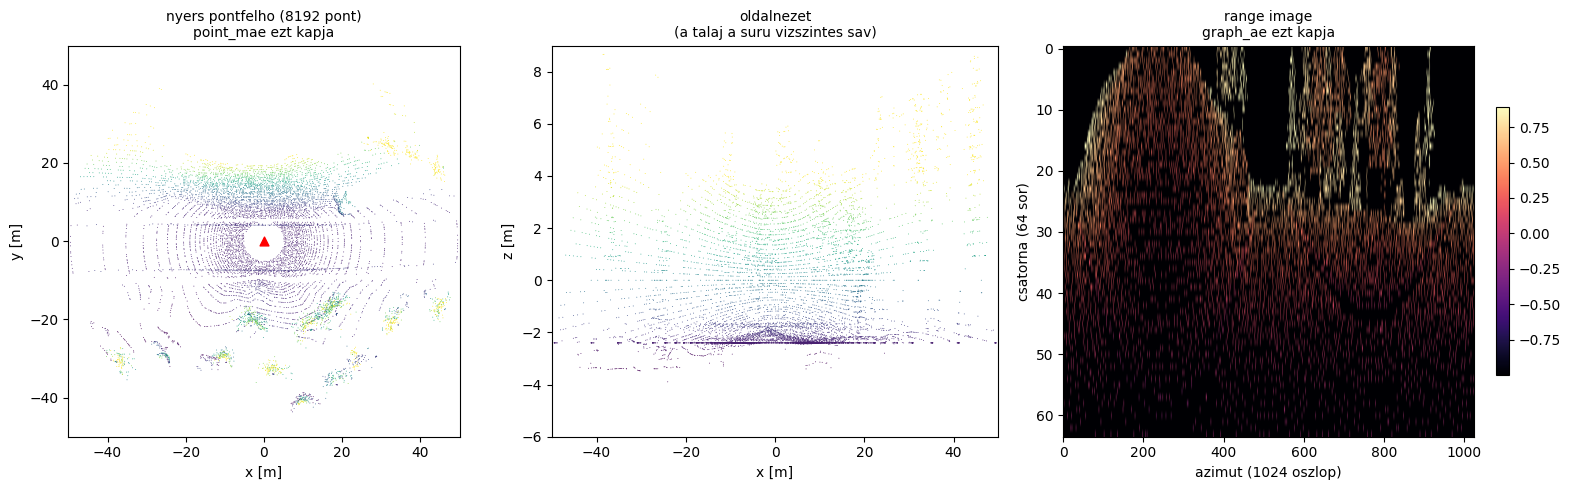

In [27]:
def show_bev(ax, pts, title="", s=0.4):
    """Madartavlati szorasdiagram, a szin a magassag."""
    ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 2], s=s, cmap="viridis",
               vmin=-3, vmax=4, linewidths=0)
    ax.scatter([0], [0], c="red", s=40, marker="^")   # az auto helye
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    if title:
        ax.set_title(title, fontsize=10)


frame = x_train[0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) nyers pontfelho felulnezetbol - ezt latja a point_mae
show_bev(axes[0], frame, f"nyers pontfelho ({len(frame)} pont)\npoint_mae ezt kapja")

# (b) oldalnezet, hogy lassuk a magassagot is
axes[1].scatter(frame[:, 0], frame[:, 2], c=frame[:, 2], s=0.4, cmap="viridis",
                vmin=-3, vmax=4, linewidths=0)
axes[1].set_xlim(-50, 50)
axes[1].set_ylim(-6, 9)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("z [m]")
axes[1].set_title("oldalnezet\n(a talaj a suru vizszintes sav)", fontsize=10)

# (c) range image - ezt latja a graph_ae
ri = points_to_range_image(frame)
im = axes[2].imshow(ri[0], cmap="magma", aspect="auto")
axes[2].set_xlabel("azimut (1024 oszlop)")
axes[2].set_ylabel("csatorna (64 sor)")
axes[2].set_title("range image\ngraph_ae ezt kapja", fontsize=10)
plt.colorbar(im, ax=axes[2], fraction=0.03)

plt.tight_layout()
plt.show()

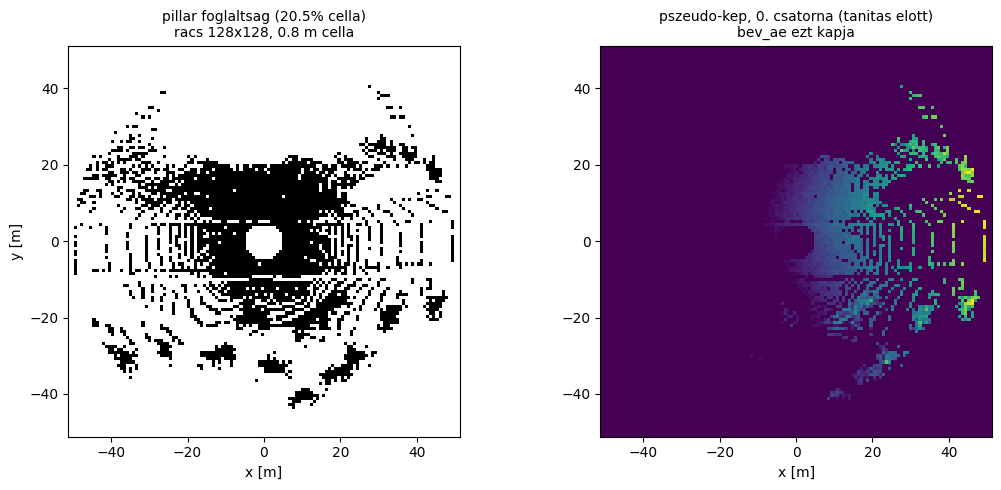

In [28]:
# A bev_ae pszeudo-kepe. Ez egy TANULT jellemzoterkep (64 csatorna), nem
# nyers adat - egy random inicializalt halon nezzuk meg, hogy lassuk a
# racsstrukturat. Tanitas utan ugyanezt megnezzuk ujra.
_probe = BEVConvAE(latent_dim=LATENT_DIM).eval()
with torch.no_grad():
    _bev = _probe.to_bev(x_train[:1])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Melyik cellaban van egyaltalan pont.
occ = (_bev[0].abs().sum(0) > 0).float().numpy()
axes[0].imshow(occ, cmap="gray_r", origin="lower",
               extent=[-51.2, 51.2, -51.2, 51.2])
axes[0].set_title(f"pillar foglaltsag ({occ.mean() * 100:.1f}% cella)\n"
                  f"racs {_probe.grid_h}x{_probe.grid_w}, 0.8 m cella", fontsize=10)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")

# Egy tanult csatorna a 64-bol.
axes[1].imshow(_bev[0, 0].numpy(), cmap="viridis", origin="lower",
               extent=[-51.2, 51.2, -51.2, 51.2])
axes[1].set_title("pszeudo-kep, 0. csatorna (tanitas elott)\nbev_ae ezt kapja",
                  fontsize=10)
axes[1].set_xlabel("x [m]")

plt.tight_layout()
plt.show()
free_vram(_probe, _bev)

### Interaktiv 3D nezet

A fenti abrak statikusak: a felulnezet elrejti a magassagot, az oldalnezet a
szelesseget. Egy pontfelhonel viszont pont a terbeli szerkezet a lenyeg -
ezert erdemes korbejarni.

Az alabbi abra **egerrel forgathato es zoomolhato**:

- bal gomb + huzas - forgatas
- gorgo - zoom
- jobb gomb + huzas (vagy ket ujj) - eltolas
- dupla klikk - visszaallas alaphelyzetbe

A szin a magassag (z). Igy latszik, ami a 2D nezetekbol nem: hol van az ut
sikja, hol allnak a falak, hol vannak jarmuvek, es mennyire ritkul a felho
kifele (a lidar sugarai legyezoszeruen nyilnak, ezert tavol egyre nagyobb a
res ket sav kozott).

In [ ]:
def show_3d(pts, title="", max_points=25000, size=1.2, extra=None,
            height=650):
    """Interaktiv 3D pontfelho a notebookban (plotly).

    pts        : (N, 3) numpy tomb vagy torch tenzor
    max_points : ennel tobb pontot leritkitunk - 25k folott a bongeszo
                 akadozni kezd, es ugyis atlathatatlan
    extra      : opcionalis lista tovabbi pontfelhokrol, amiket ra akarunk
                 rajzolni: [(pontok, "nev", "szin", meret), ...]
    """
    pts = pts.cpu().numpy() if hasattr(pts, "cpu") else np.asarray(pts)

    # Ritkitas, hogy a bongeszo ne akadjon meg.
    if len(pts) > max_points:
        sel = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts = pts[sel]

    traces = [go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=size, color=pts[:, 2], colorscale="Viridis",
                    cmin=-3, cmax=4, opacity=0.85,
                    colorbar=dict(title="z [m]", thickness=12, len=0.6)),
        name=f"pontfelho ({len(pts)})",
        hovertemplate="x %{x:.1f}<br>y %{y:.1f}<br>z %{z:.1f}<extra></extra>",
    )]

    # Az auto helye: a lidar az origoban van (x=0, z=2.4 a szenzor magassaga,
    # de a pontok mar a szenzorhoz kepest vannak megadva).
    traces.append(go.Scatter3d(
        x=[0], y=[0], z=[0], mode="markers",
        marker=dict(size=6, color="red", symbol="diamond"),
        name="ego (lidar)", hoverinfo="name"))

    for e_pts, e_name, e_color, e_size in (extra or []):
        e_pts = e_pts.cpu().numpy() if hasattr(e_pts, "cpu") else np.asarray(e_pts)
        traces.append(go.Scatter3d(
            x=e_pts[:, 0], y=e_pts[:, 1], z=e_pts[:, 2], mode="markers",
            marker=dict(size=e_size, color=e_color), name=e_name))

    fig = go.Figure(traces)
    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=0, r=0, t=40 if title else 0, b=0),
        legend=dict(x=0, y=1),
        scene=dict(
            # aspectmode="data": a harom tengely ARANYA a valos meretekbol
            # jon. Enelkul a plotly kockara nyujtja a jelenetet, es a lapos
            # ut-sik magasnak tunne.
            aspectmode="data",
            xaxis_title="x [m]  (elore)",
            yaxis_title="y [m]  (balra)",
            zaxis_title="z [m]  (fel)",
            # Kezdo kameraallas: kicsit hatulrol-felulrol, mint egy
            # kovetokamera - igy egybol felismerheto a jelenet.
            camera=dict(eye=dict(x=-1.4, y=-1.4, z=0.9)),
        ),
    )
    fig.show()


show_3d(x_train[0], title="Nyers CARLA lidar pontfelho - forgasd el!")

## 3. Kozos tanito fuggvenyek

**Itt egy fontos kulonbseg a kamera notebookhoz kepest.** Ott mindharom modell
ugyanazzal az MSE-vel tanult, igy a loss szamok kozvetlenul osszemerhetok
voltak. Itt EZ NEM LEHETSEGES, mert a harom modell mas celt rekonstrual:

| modell | loss | mit mer |
|---|---|---|
| `point_mae` | Chamfer | a maszkolt patch-ek pontjainak tavolsaga, **meter^2** |
| `bev_ae` | MSE | a BEV jellemzoterkep hibaja, **dimenziotlan** |
| `graph_ae` | L1 | a range image hibaja, **[-1, 1] skalan** |

Ezert a nyers loss-okat NEM hasonlitjuk ossze egymassal - csak azt nezzuk,
hogy egy modell tanul-e (csokken-e a sajat gorbeje). A vegen a 7. szekcioban
van egy KOZOS metrika, ami mindharomra ugyanazt meri.

A tanito fuggveny viszont kozos: ugyanaz az optimizer, ugyanaz az early
stopping, ugyanaz a checkpoint formatum.

In [30]:
def evaluate(model, data, batch):
    """Atlagos loss a teljes adathalmazon."""
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(data), batch):
            xb = data[i:i + batch].to(DEVICE, non_blocking=True).float()
            total += float(model.loss(xb)) * len(xb)
            n += len(xb)
    return total / n


def train_model(model, label, batch, train_data, val_data,
                epochs=EPOCHS, lr=1e-3, patience=5, cosine=False,
                resume=True):
    """Tanitas a TELJES train halmazon, MEGSZAKITHATO es FOLYTATHATO.

    train_data / val_data: az adott modell sajat bemeneti tenzora -
        bev_ae, point_mae : x_train / x_val   (8192 pontos felhok)
        graph_ae          : r_train / r_val   (range image a teljes felhobol)

    A .float() a batch-en azert kell, mert a `ranges` float16-ban van tarolva
    (feleannyi RAM), a halok viszont float32-ben szamolnak.

    ---------------------------------------------------------------------
    FOLYTATAS (resume=True, ez az alapertelmezes)
    ---------------------------------------------------------------------
    MINDEN EPOCH VEGEN mentunk, nem csak a futas vegen. A checkpoint
    tartalmazza a folytatashoz kello MINDEN allapotot:

        state_dict      - az aktualis sulyok (nem a legjobb!)
        best_state      - a legjobb val loss-hoz tartozo sulyok
        optimizer       - az Adam momentum-allapota. ENELKUL a folytatas
                          ugy indulna, mintha nulla lendulettel kezdenenk,
                          es az elso par epoch elrontana a tanulast.
        sched           - a cosine scheduler allapota (hol tart a leszallo ag)
        epoch           - hany epoch futott le mar
        train / val     - az eddigi gorbek, hogy az abra teljes legyen
        bad             - hany epoch telt el javulas nelkul (early stopping)

    Ha megszakitod (Ctrl+C / kernel leallitas / aramszunet), csak inditsd
    ujra UGYANEZT a cellat: onnan folytatja, ahol abbahagyta.

    Ha ELOLROL akarod kezdeni, add at a `resume=False`-t, vagy toröld a
    `lidar/<label>.ckpt` fajlt.

    A visszaadott dict tartalmazza a gorbeket es a ckpt utvonalat, de a
    MODELLT NEM - az a tanitas vegen lekerul a GPU-rol es felszabadul.
    """
    model = model.to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    # cosine: a learning rate a futas soran fokozatosan 0 fele megy, igy a
    # vegen finomhangol a nagy lepesek helyett. Merve a point_mae-nel -1.7%.
    sched = (torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
             if cosine else None)

    hist = {"label": label, "arch": type(model).__name__,
            "train": [], "val": [], "best": float("inf"),
            "params": sum(p.numel() for p in model.parameters()),
            "ckpt": f"lidar/{label}.ckpt"}
    best_state, bad, start_ep = None, 0, 1

    # --- FOLYTATAS a mentett checkpointbol -----------------------------
    if resume and os.path.exists(hist["ckpt"]):
        ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
        # Csak akkor folytatunk, ha UGYANARROL a modellrol van szo. Ha kozben
        # atirtad az architekturat, a sulyok alakja nem egyezne - olyankor
        # inkabb elolrol kezdunk, mint hogy hibaval elszalljon.
        if ck.get("arch") == hist["arch"] and "epoch" in ck:
            try:
                model.load_state_dict(ck["state_dict"])
                opt.load_state_dict(ck["optimizer"])
                if sched is not None and ck.get("sched") is not None:
                    sched.load_state_dict(ck["sched"])
                hist["train"] = list(ck.get("train", []))
                hist["val"] = list(ck.get("val", []))
                hist["best"] = ck.get("best_val", float("inf"))
                best_state = ck.get("best_state", ck["state_dict"])
                bad = ck.get("bad", 0)
                start_ep = ck["epoch"] + 1
                if start_ep > epochs:
                    print(f"{label}: mar lefutott {ck['epoch']} epoch "
                          f"(best val {hist['best']:.5f}). Emeld az `epochs` "
                          f"erteket, vagy add at a resume=False-t az "
                          f"ujrakezdeshez.")
                    model.load_state_dict(best_state)
                    hist["epochs_run"] = len(hist["train"])
                    hist["time"] = 0.0
                    return hist, model
                print(f"{label}: FOLYTATAS a {ck['epoch']}. epoch utan "
                      f"(best val {hist['best']:.5f})")
            except (RuntimeError, KeyError) as e:
                print(f"{label}: a checkpoint nem illeszkedik ({type(e).__name__}), "
                      f"elolrol kezdjuk")
                best_state, bad, start_ep = None, 0, 1
                hist["train"], hist["val"], hist["best"] = [], [], float("inf")
        else:
            print(f"{label}: regi formatumu vagy mas architekturaju checkpoint, "
                  f"elolrol kezdjuk")

    print(f"{label}  ({hist['params'] / 1e6:.1f}M parameter, lr={lr}, "
          f"batch={batch}, {len(train_data)} train frame, "
          f"epoch {start_ep}-{epochs})")
    t0 = time.time()

    for ep in range(start_ep, epochs + 1):
        model.train()
        run, n = 0.0, 0
        perm = torch.randperm(len(train_data))
        bar = tqdm(range(0, len(train_data), batch), desc=f"epoch {ep}/{epochs}",
                   leave=False)
        for i in bar:
            xb = train_data[perm[i:i + batch]].to(DEVICE, non_blocking=True).float()
            loss = model.loss(xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            run += float(loss.detach()) * len(xb)
            n += len(xb)
            bar.set_postfix(loss=f"{float(loss.detach()):.5f}")

        if sched is not None:
            sched.step()

        tr = run / n
        va = evaluate(model, val_data, batch)
        hist["train"].append(tr)
        hist["val"].append(va)

        # Early stopping: ha `patience` epochon at nem javul a val loss,
        # megallunk. A tullanulas ellen ved es idot sporol.
        improved = va < hist["best"]
        if improved:
            hist["best"], bad = va, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1

        # MENTES MINDEN EPOCH VEGEN - ez teszi folytathatova a futast.
        # Eloszor egy .tmp fajlba irunk, aztan atnevezzuk: igy ha pont mentes
        # kozben szakad meg a futas, a regi checkpoint epen marad.
        tmp = hist["ckpt"] + ".tmp"
        torch.save({"state_dict": {k: v.detach().cpu()
                                   for k, v in model.state_dict().items()},
                    "best_state": best_state,
                    "optimizer": opt.state_dict(),
                    "sched": sched.state_dict() if sched is not None else None,
                    "epoch": ep,
                    "bad": bad,
                    "hparams": (dict(model.hparams) if hasattr(model, "hparams")
                                else {}),
                    "arch": hist["arch"],
                    "best_val": hist["best"],
                    "train": hist["train"], "val": hist["val"]}, tmp)
        os.replace(tmp, hist["ckpt"])

        print(f"  epoch {ep:2d}  train {tr:.5f}  val {va:.5f}"
              f"  [{(time.time() - t0) / 60:.0f} perc]"
              f"{'  *' if improved else ''}")

        if bad >= patience:
            print(f"  early stop ({patience} epoch javulas nelkul)")
            break

    # A LEGJOBB sulyokat adjuk vissza, nem az utolsokat.
    model.load_state_dict(best_state)
    hist["epochs_run"] = len(hist["train"])
    hist["time"] = time.time() - t0

    print(f"  kesz: {hist['ckpt']}  (best val {hist['best']:.5f}, "
          f"{hist['time'] / 60:.1f} perc ebben a futasban)")
    return hist, model


def plot_history(hist, ylabel="loss"):
    """Egy modell tanulasi gorbeje."""
    ep = range(1, len(hist["train"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(ep, hist["train"], "-o", ms=3, label="train")
    plt.plot(ep, hist["val"], "-s", ms=3, label="val")
    plt.axhline(hist["best"], ls=":", c="gray",
                label=f"best val {hist['best']:.5f}")
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.yscale("log")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(f"{hist['label']}  ({hist['params'] / 1e6:.1f}M parameter)")
    plt.tight_layout()
    plt.show()

## 4. `bev_ae`

### Felepites

A PointPillars pillar-encodere + egy konvolucios autoencoder:

```
(4096, 3) pont
  -> pillar voxelizacio: 128x128-as racs, 0.8 m-es cella
  -> PillarFeatureNet (mini-PointNet oszloponkent) -> (64, 128, 128) pszeudo-kep
  -> 4 db Conv2d(k=4, s=2) -> (256, 8, 8) -> flatten -> Linear -> 128
```

Innentol ez pontosan ugyanaz, mint a `camera_ae`: egy kep-autoencoder. A
kulonbseg, hogy a "kep" nem RGB, hanem egy **tanult 64 csatornas
jellemzoterkep**, es a rekonstrukcios loss is erre megy.

> **Miert oszlop (pillar) es nem kocka (voxel)?** Mert a vezetesnel a
> magassag kevesbe erdekes, mint a felulnezeti elrendezes. Ha a magassag
> mentén is vagnank, harmadik dimenziot kapnank a racsban, ami
> nagysagrendekkel dragabb - a PointPillars pont azzal lett gyors, hogy ezt
> elhagyta.

In [ ]:

# EPOCH-SZAM: 80, nem a kozos 30.
# Az elso teljes futas 30 epochnal ELFOGYOTT, nem early stoppal allt le:
#   epoch 27  train 0.91457  val 0.92859  *
#   epoch 29  train 0.90903  val 0.92475  *     <- meg mindig javult
# Tullanulas nincs (train 0.909 / val 0.925 egyutt megy le), tehat nyugodtan
# mehet tovabb. Egy epoch ~3 perc, tehat 80 epoch ~4 ora; az early stopping
# (patience=5) leallitja, amint tenyleg beall.
#
# A LATENS MARAD 128. A tomorites itt 8192:1 (a pszeudo-kep 64x128x128 =
# 1048576 erteke megy 128 szamba), ami sokkal agresszivebb, mint a graph_ae
# 256:1-e vagy a kamera AE 600:1-e - tehat ELKEPZELHETO, hogy a latens a szuk
# keresztmetszet. De ezt NEM mertuk ki, ezert nem is nyulunk hozza: eloszor a
# bizonyitottan keves epochot javitjuk.
#
# Ha 80 epoch utan is javul meg a gorbe, VAGY beall egy magas erteken, akkor
# erdemes megmerni a latenst (128 vs 256 vs 512) - addig a nagyobb latens csak
# tippeles lenne, raadasul az RL observationben is nagyobb helyet foglalna
# (az SB3 MultiInputPolicy NEM normalizal, tehat elnyomna a sebesseget,
# kormanyt, waypointokat).
#
# ERTELMEZES: a cel varianciaja ~2.59, tehat az MSE 0.92 azt jelenti, hogy a
# modell a variancia 64%-at magyarazza (R^2 = 0.64). Ez nem "10% hiba" -
# a BEV pszeudo-kep nem [0,1] skalara normalizalt kep, hanem tanult
# jellemzoterkep.
EPOCHS_BEV = 80

model = BEVConvAE(latent_dim=LATENT_DIM)
hist_bev_ae, model = train_model(model, label="bev_ae", batch=32, lr=1e-3,
                                 train_data=x_train, val_data=x_val,
                                 epochs=EPOCHS_BEV, cosine=True)

plot_history(hist_bev_ae, ylabel="MSE (pszeudo-kep)")

bev_ae  (5.7M parameter, lr=0.001, batch=32, 46178 train frame, epoch 1-80)


epoch 1/80:   0%|          | 0/1444 [00:00<?, ?it/s]

  epoch  1  train 1.51970  val 1.34779  [3 perc]  *


epoch 2/80:   0%|          | 0/1444 [00:00<?, ?it/s]

  epoch  2  train 1.29199  val 1.24249  [7 perc]  *


...

epoch 25/80:   0%|          | 0/1444 [00:00<?, ?it/s]

  epoch 25  train 0.92219  val 0.93919  [80 perc]  *


epoch 26/80:   0%|          | 0/1444 [00:00<?, ?it/s]

  epoch 26  train 0.91979  val 0.93809  [83 perc]  *


epoch 27/80:   0%|          | 0/1444 [00:00<?, ?it/s]

In [ ]:
# VRAM felszabaditasa a kovetkezo modell elott.
# A sulyok mar a lidar/bev_ae.ckpt fajlban vannak, a modell elengedheto.
free_vram(model)
print("bev_ae utan:", vram())

## 5. `graph_ae`

### Felepites

A szenzor sajat geometriaja szerint **range image**-be teriti a felhot: 64 sor
(a lidar 64 csatornaja) x 1024 oszlop (azimut), a pixelertek a tavolsag. Ez
vesztesegmentes atteres, mert pont igy keletkezik az adat a szenzorban.

```
(4096, 3) pont -> (1, 64, 1024) range image
  -> Stem (downsampling) -> (64, 16, 128)
  -> 4 dinamikus graf-reteg (kNN a jellemzoterben, retegenkent ujraszamolva)
  -> (16, 16, 128) = 32768 ertek
  -> flatten -> Linear -> tanh -> 128            <- a szuk keresztmetszet
```

> **Miert kell a szuk keresztmetszet?** A `LidarAE` sajat latense
> 16*128*16 = **32768 ertek**, 256-szorosa a masik ket modellenek. Igy nem
> lehetne osszehasonlitani oket, es az RL-be kotve is bajt okozna: az SB3
> `MultiInputPolicy` NEM normalizal, tehat a 32768 elemu vektor elnyomna a
> tobbi observationt (steer, throttle, waypointok). Ezert a burkolo
> osztalyban jon egy `Linear(32768, 128)`, ugyanaz a recept, mint a
> `camera_ae` conv stackje utan.
>
> **A `graph_ae.py`-hoz nem nyulunk** - a bottleneck a notebookban el.

> **Ket tovabbi kulonbseg:**
> - `lr=1e-4`, nem `1e-3` - ez a modell sajat `configure_optimizers()`
>   beallitasa (`betas=(0.5, 0.9)` mellett).
> - A `Linear` par onmagaban **+8.4M parameter**, tehat a modell 7.8M-rol
>   ~16M-re no. Ez az ara annak, hogy egy 32768 elemu terbeli latenst
>   egyetlen 128 elemu vektorra viszunk le.

In [ ]:
# A range image mar KESZ (`r_train` / `r_val`), a 2. szekcioban szamoltuk ki
# a TELJES nyers felhobol - nem a leritkitottbol. Ez a modell tehat egyetlen
# pontot sem veszit: mind a ~10600 pont belekerult a kepbe.
#
# Ket haszon ezen kivul:
#   - a kitoltottseg 11.9% helyett 15.6% (a maximum)
#   - a CPU-s prep eltunt a tanito ciklusbol


# A LidarAE nem Lightning modul es nincs sajat loss() metodusa - a kozos
# train_model() viszont azt hivja. Egy vekony burkolo megoldja.
#
# A burkolo egyben a SZUK KERESZTMETSZETET is hozza: a LidarAE sajat latense
# (16, 16, 128) = 32768 ertek, ami 256-szorosa a masik ket modellenek. Egy
# Linear par leviszi 128-ra, ugyanugy, ahogy a camera_ae csinalja a conv
# stack utan. Igy mindharom modell azonos meretu latenst ad.
#
# FONTOS: a graph_ae.py-hoz NEM nyulunk. A bottleneck itt el, a notebookban -
# ha nem valik be, eleg ezt a cellat atirni.
class GraphAEWrapper(torch.nn.Module):
    """LidarAE + 128 dimenzios szuk keresztmetszet + loss().

    latent_dim=None eseten a LidarAE eredeti (16, 16, 128) latense marad.
    """

    def __init__(self, latent_dim=LATENT_DIM, latent_scale=4.0, **kwargs):
        super().__init__()
        self.net = LidarAE(DDCONFIG, **kwargs)
        self.latent_dim = latent_dim
        self.latent_scale = latent_scale

        if latent_dim is not None:
            # Az encoder kimenete (B, z_channels, 16, 128). A 16x128 a DDCONFIG
            # stride-jaibol jon: 64/4 = 16 sor, 1024/8 = 128 oszlop.
            self.spatial = (DDCONFIG["z_channels"], 16, 128)
            flat = self.spatial[0] * self.spatial[1] * self.spatial[2]  # 32768
            self.fc_encode = torch.nn.Linear(flat, latent_dim)
            self.fc_decode = torch.nn.Linear(latent_dim, flat)

    def encode(self, x):
        """Range image -> latens. EZT hasznalja majd az RL."""
        z = self.net.encode(x)
        if self.latent_dim is None:
            return z
        # tanh korlatozza a latenst [-scale, scale] koze, mert az RL
        # observation-space-nek veges hatarai vannak.
        return torch.tanh(self.fc_encode(z.flatten(1))) * self.latent_scale

    def decode(self, z):
        if self.latent_dim is not None:
            z = self.fc_decode(z / self.latent_scale).view(-1, *self.spatial)
        return self.net.decode(z)

    def forward(self, x):
        return self.decode(self.encode(x))

    def loss(self, x):
        # L1 a range image-en - ezt ajanlja a graph_ae sajat docstringje is.
        #
        # MIERT NEM MSE: a range image 84%-a URES (-1), 16%-aban van pont
        # (~+0.4), tehat ket modusz kozott eles hatarok vannak - merve a
        # szomszedos cellak kulonbsege a p99-en 1.84. Egy ilyen elnel az MSE
        # a "biztonsagos kozepet" jutalmazza (negyzetes bunteteskent olcsobb,
        # mint rosszul donteni), ezert ELMOSSA a targyak hataret. Az L1
        # optimuma a median, ami ketmoduszu adatnal az egyik valodi modusz -
        # tehat eles marad.
        #
        # Az RL-nek pont az szamit, HOL VEGZODIK egy auto, ezert itt az
        # eles hatar tobbet er, mint az egyseges elnevezes.
        return F.l1_loss(self(x), x)


# BATCH=8. Ezen a kartyan (16 GB) merve:
#   batch  4 ->  4.14 GB csucs,  29.9 frame/s
#   batch  8 ->  8.06 GB csucs,  29.2 frame/s
#   batch 12 -> 11.98 GB csucs,  28.6 frame/s
#
# EZ A MODELL A LASSU, ES NEM A MEMORIA MIATT. Barmelyik batch-mereten
# ~29 frame/s - a dinamikus graf-retegek (retegenkent ujraszamolt kNN a
# jellemzoterben) es a 64x1024-es dekoder a koltseg. A nagyobb batch itt nem
# gyorsit, csak a VRAM-ot viszi.
#
# IDOIGENY - EZ A LEGDRAGABB MODELL.
# 46178 train frame / 29 frame/s = ~26.5 PERC EPOCHONKENT (+ validacio),
# tehat 30 epoch ~13-14 ORA. A masik ketto egyutt ~5 ora.
#
# EPOCHS_GRAPH allitja. Amit tudni erdemes a valasztashoz:
#   - a masik ket modellnel a 30 epoch KEVESNEK bizonyult (mindketto meg
#     javult az utolso epochban), ezert ott 80-ra / 120-ra emeltuk
#   - itt viszont minden epoch 26 perc, tehat a 80 mar 35 ora lenne
#   - az early stopping (patience=5) barmikor leallitja, ha beall
#
# 30 a kompromisszum: egy ejszaka alatt lefut. Ha reggel azt latod, hogy az
# utolso epoch meg `*`-ot kapott (tehat javult), akkor ezt emelni kell - vagy
# folytatni a mentett checkpointbol.
# 10 EPOCH ELOSZOR, nem 30. Indoklas:
#
# Ez a legdragabb modell minden szempontbol:
#   tanitas   : 26.5 perc/epoch -> 30 epoch = 13 ora (a masik ketto egyutt 1.5)
#   inferencia: 29 frame/s      -> a point_mae 1188, tehat 40x gyorsabb
#   parameter : 16.2M           -> ebbol 8.4M maga a Linear(32768, 128)
#
# Az INFERENCIA a fontosabb: az encoder MINDEN RL lepesben lefut. A CARLA
# 20 Hz-cel megy, tehat 29 frame/s epphogy valos ido, tartalek nelkul.
#
# Viszont ez az egyetlen modell, ami a pontok 100%-at hasznalja (a masik ketto
# 77%-ot), es a szenzor natv geometriajat orzi - elvileg ez adhatja a legjobb
# jelet. De ez HIPOTEZIS, nem mert teny.
#
# Ezert: eloszor 10 epoch (~4.5 ora), es a 7. szekcio megmutatja a latens
# simasagat - AZ a dontő szam az RL szempontjabol. Ha kiemelkedo, EMELD EZT
# 30-ra es futtasd ujra ezt a cellat: a resume onnan folytatja, ahol
# abbahagyta, nem kezdi elolrol. Ha gyenge, sporoltal 8 orat.
EPOCHS_GRAPH = 10

model = GraphAEWrapper()
hist_graph_ae, model = train_model(model, label="graph_ae", batch=8, lr=1e-4,
                                   train_data=r_train, val_data=r_val,
                                   epochs=EPOCHS_GRAPH, cosine=True)

plot_history(hist_graph_ae, ylabel="L1 (range image)")

In [ ]:
# VRAM felszabaditasa az osszehasonlitas elott.
# A sulyok mar a lidar/graph_ae.ckpt fajlban vannak, a modell elengedheto.
free_vram(model)
print("graph_ae utan:", vram())

## 6. `point_mae`

> **Ez a modell van a vegen, szandekosan.** Az architekturajat 13
> konfiguracio kimeresevel valasztottuk ki (lasd a kodcellat), es igy a
> leghosszabb futas is a sor vegere kerul - a masik ket modell addigra mar
> lementette a sajat checkpointjat.

### Felepites

A pontfelhot **patch-ekre** bontja, ugy, ahogy a ViT egy kepet:

```
(4096, 3) pont
  -> FPS: 64 kozeppont       egyenletesen szorva a terben
  -> kNN: 32 pont mindegyik kore
  -> (64, 32, 3) patch, mindegyik a sajat kozeppontjahoz normalizalva
  -> mini-PointNet -> (64, 192) token
```

Aztan a patch-ek **60%-at eltakarja**, es csak a maradek 40%-ot adja az
encodernek. A decoder feladata a hianyzo patch-ek visszaepitese.

> **Miert a maszkolas?** Egy sima "epitsd vissza a bemenetet" feladatot a
> halo trivialisan megold (eleg atlagolnia). Ha viszont a felho 60%-a
> hianyzik, a kitoltesehez tenyleg erteni kell a geometriat: hogy az ut sik,
> a fal fuggoleges, az auto doboz alaku.

> **Miert Chamfer es nem MSE?** Az MSE az i-edik josolt pontot az i-edik
> valodihoz parositja, de a pontfelhoben nincs sorrend. KIMERTUK egy teljes
> MSE-s futassal (30 epoch): a val loss 4.43 -> 3.73 ment (16% javulas), es a
> kapott modell Chamferrel merve **10.51** - a Chamferrel tanitott 2.51-hez
> kepest **4x rosszabb geometria**.
>
> A modellt kulon megvizsgalva kiderult, mire ment el az energia:
> a josolt pontok atlagosan **0.84 m**-re vannak a legkozelebbi valodi
> ponttol (tehat a geometria nagyjabol megvan), de **2.70 m**-re az azonos
> indexutol - es az MSE ez utobbit bunteti. A halo a SORRENDET probalta
> tanulni, ami rendezetlen pontfelhonel megoldhatatlan.

In [ ]:
# ARCHITEKTURA: KIMERVE, nem tippelve.
# 13 konfiguraciot futtattam azonos adaton (5000 frame, Chamfer, 15 epoch):
#
#   konfiguracio                          val     megjegyzes
#   --------------------------------------------------------------------
#   alap (ng=64, gs=32, dec=2)          3.9087   a kiindulas
#   decoder_depth=4                     3.5217   -10%
#   decoder_depth=4 + cosine lr         3.4602
#   num_group=128, gs=32, dec=4         2.4685   -37%
#   num_group=128, gs=16, dec=4         2.3051   -41%  <- EZ
#
#   AMI NEM MUKODOTT:
#   embed_dim=384 (14.9M param)         4.0454   ROSSZABB a 4.07M alapnal
#   encoder_depth=8                     3.5028   nem valtoztat
#   mask_ratio=0.45 (konnyebb)          3.9684   rosszabb
#   mask_ratio=0.75 (nehezebb)          3.4646   rosszabb
#
# A TANULSAG: a modell nem KAPACITAS-hianyos volt, hanem INFORMACIO-hianyos.
# A nagyobb halo (embed_dim=384, 3.7x parameter) ROSSZABB lett. Ami szamit:
# hany helyen mintaveteli a teret. Az alap 64 patch x 32 pont = 2048 pontot
# latott a 8192-bol; most 128 patch x 16 pont, tehat ugyanannyi pontot, de
# KETSZER annyi helyrol - finomabb terbeli felbontas.
#
# (Ezert nem szamitott annyit az N_POINTS 4096 -> 8192 emelese sem: a szuk
# keresztmetszet nem a betoltesnel volt, hanem itt, a patch-kepzesnel.)
#
# BATCH=64: merve 5.3 GB csucs, 1188 frame/s. A 128 csak 4%-ot gyorsit
# duplaannyi VRAM-ert, es nagy batch-nel kevesebb gradienslepes jut egy
# epochra. A num_group=128 valamivel tobbet eszik - ha OOM lenne, vidd 32-re.
model = PointMAE(latent_dim=LATENT_DIM, num_group=128, group_size=16,
                 decoder_depth=4)

# COSINE LEARNING RATE: a lr 1e-3-rol fokozatosan 0 fele megy, igy a vegen
# finomhangol. Merve -1.7% (3.5217 -> 3.4602). FIGYELEM: 10 epochon meg NEM
# segitett (5.689 fix vs 5.741 cosine) - csak akkor eri meg, ha van eleg
# epoch, hogy a leszallo ag kifejtse a hatasat.
hist_point_mae, model = train_model(model, label="point_mae", batch=64, lr=1e-3,
                                    train_data=x_train, val_data=x_val,
                                    cosine=True)

plot_history(hist_point_mae, ylabel="Chamfer [m^2]")

In [ ]:
# VRAM felszabaditasa a kovetkezo modell elott.
# A sulyok mar a lidar/point_mae.ckpt fajlban vannak, a modell elengedheto.
free_vram(model)
print("point_mae utan:", vram())

## 7. Osszehasonlitas

Mindharom modell **ugyanazokon a validacios frameken**, amiket egyik sem latott
tanitas kozben. A modelleket a mentett checkpointokbol toltjuk vissza.

A nyers loss-ok NEM osszemerhetok (mas celt rekonstrualnak, mas
mertekegysegben - lasd a 3. szekciot). Ezert harom dolgot nezunk, ami
mindharomra ugyanazt jelenti:

1. **Latens minoseg** - kihasznalja-e a modell a 128 dimenziot, vagy sok a
   halott / telitett dimenzio.
2. **Latens simasag** - idoben szomszedos framek latensei mennyire vannak
   kozel egymashoz. **Ez a legfontosabb szam az RL szempontjabol:** ha ket
   szomszedos frame (0.05 s) latense nagyot ugrik, az agent zajt lat allapot
   helyett, es a tanulas instabil lesz.
3. **Rekonstrukciok szemmel** - mit epit vissza a halo.

In [ ]:
def load_model(hist):
    """Modell visszatoltese a checkpointbol."""
    ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
    arch = ck["arch"]
    if arch == "PointMAE":
        m = PointMAE(**ck["hparams"])
    elif arch == "BEVConvAE":
        m = BEVConvAE(**ck["hparams"])
    else:
        m = GraphAEWrapper()
    # A LEGJOBB sulyokat toltjuk vissza. Az uj formatumban a
    # "state_dict" az UTOLSO allapot (a folytatashoz kell), a
    # "best_state" pedig a legjobb val loss-hoz tartozo.
    m.load_state_dict(ck.get("best_state") or ck["state_dict"])
    return m.eval()


# A futtatas sorrendjeben: bev_ae -> graph_ae -> point_mae.
HISTORIES = [hist_bev_ae, hist_graph_ae, hist_point_mae]

# Melyik modell melyik VAL tenzorbol dolgozik. Ugyanazok a framek, csak mas
# reprezentacioban - a 2. szekcioban kozos permutacioval vagtuk oket, tehat
# az osszehasonlitas ervenyes.
VAL_DATA = {"bev_ae": x_val, "graph_ae": r_val, "point_mae": x_val}

# Eval batch: NAGYOBB a tanitasinal, mert itt csak `torch.no_grad()`
# inferencia fut - nem kell tarolni az aktivaciokat a backwardhoz.
# Merve: point_mae 1.64 GB, bev_ae 4.98 GB, graph_ae 1.08 GB.
EVAL_BATCH = {"bev_ae": 32, "graph_ae": 16, "point_mae": 128}

print("Mentett checkpointok:")
for h in HISTORIES:
    size = os.path.getsize(h["ckpt"]) / 1e6
    print(f"  {h['ckpt']:28s} {size:6.1f} MB   best val {h['best']:.5f}")

In [ ]:
# --- Tanulasi gorbek egymas mellett ---
# KULON abran, mert mas a mertekegysegük - egy abrara rakva az egyik gorbe
# lelapulna a masik mellett, es nem latszana, tanul-e egyaltalan.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
units = ["MSE (pszeudo-kep)", "L1 (range image)", "Chamfer [m^2]"]

for ax, h, unit in zip(axes, HISTORIES, units):
    ep = range(1, len(h["train"]) + 1)
    ax.plot(ep, h["train"], "-o", ms=3, label="train")
    ax.plot(ep, h["val"], "-s", ms=3, label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(unit)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_title(f"{h['label']}  ({h['params'] / 1e6:.1f}M param)", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- Szamszeru osszefoglalo ---
# A 'val loss' oszlop NEM osszehasonlithato a sorok kozott (mas metrika),
# csak azt mutatja, hova jutott az adott modell a sajat celfuggvenyen.

print(f"{'modell':12s} {'val loss':>10s} {'metrika':>18s} {'latens':>9s} "
      f"{'param':>8s} {'epoch':>6s} {'perc':>6s}")
print("-" * 78)

for h, unit in zip(HISTORIES, units):
    print(f"{h['label']:12s} {h['best']:10.5f} {unit:>18s} "
          f"{LATENT_DIM:9d} {h['params'] / 1e6:7.1f}M "
          f"{h['epochs_run']:6d} {h['time'] / 60:6.1f}")

print(f"\nMindharom latens {LATENT_DIM} dimenzios, tehat barmelyik kozvetlenul")
print("beköthetö az RL observationbe.")

In [ ]:
# --- Rekonstrukciok: mit epit vissza a ket pontfelho-alapu modell? ---
#
# A point_mae a MASZKOLT patch-eket epiti vissza - a kek pontok a lathato
# resz (amit az encoder latott), a piros a rekonstrualt hianyzo resz.

n = 3
idx = np.random.choice(len(x_val), n, replace=False)
sample = x_val[idx]

m = load_model(hist_point_mae).to(DEVICE)
with torch.no_grad():
    rebuild, gt, mask, center = m(sample.to(DEVICE))
free_vram(m)

rebuild, gt, mask, center = (t.cpu() for t in (rebuild, gt, mask, center))

fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5.5))
for j in range(n):
    vis_c = center[j][~mask[j]]
    mask_c = center[j][mask[j]]
    # A patch-ek lokalis koordinatait vissza kell tolni a kozeppontjukra.
    rec_pts = (rebuild[j] + mask_c.unsqueeze(1)).reshape(-1, 3)

    ax = axes[j]
    ax.scatter(sample[j][:, 0], sample[j][:, 1], s=0.3, c="lightgray",
               linewidths=0, label="teljes felho")
    ax.scatter(vis_c[:, 0], vis_c[:, 1], s=45, c="tab:blue", marker="o",
               label=f"lathato kozeppont ({len(vis_c)})")
    ax.scatter(rec_pts[:, 0], rec_pts[:, 1], s=1.5, c="tab:red", linewidths=0,
               label=f"rekonstrualt ({len(mask_c)} patch)")
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")
    if j == 0:
        ax.set_ylabel("y [m]")
        ax.legend(fontsize=8, loc="upper right", markerscale=2)
    ax.set_title(f"point_mae rekonstrukcio #{j}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# --- Ugyanaz 3D-ben, interaktivan ---
#
# A felulnezeten nem latszik, hogy a rekonstruktalt pontok a helyes
# MAGASSAGBAN vannak-e. Itt korbe lehet jarni: ha a piros pontok a szurke
# felho felszinen ulnek, a modell megtanulta a geometriat; ha a levegoben
# lebegnek vagy a foldbe fulnak, nem.

j = 0                                    # melyik mintat nezzuk a harombol
mask_c_j = center[j][mask[j]]
rec_pts_j = (rebuild[j] + mask_c_j.unsqueeze(1)).reshape(-1, 3)
gt_pts_j = (gt[j] + mask_c_j.unsqueeze(1)).reshape(-1, 3)

show_3d(
    sample[j],
    title=f"point_mae rekonstrukcio 3D  -  {len(mask_c_j)} maszkolt patch",
    extra=[
        (gt_pts_j, f"valodi (maszkolt) pontok", "limegreen", 2.0),
        (rec_pts_j, f"rekonstrualt pontok", "red", 2.0),
        (center[j][~mask[j]], "lathato patch-kozeppontok", "royalblue", 4.0),
    ],
)

In [ ]:
# --- bev_ae: a pszeudo-kep es a rekonstrukcioja ---
m = load_model(hist_bev_ae).to(DEVICE)
with torch.no_grad():
    bev = m.to_bev(sample.to(DEVICE))
    rec = m.decode(m.encode_bev(bev))
bev, rec = bev.cpu(), rec.cpu()
free_vram(m)

fig, axes = plt.subplots(2, n, figsize=(5 * n, 9))
for j in range(n):
    # A 64 csatorna atlaga - egy csatorna onmagaban nehezen olvashato.
    axes[0, j].imshow(bev[j].mean(0), cmap="viridis", origin="lower",
                      extent=[-51.2, 51.2, -51.2, 51.2])
    axes[0, j].set_title(f"eredeti pszeudo-kep #{j}", fontsize=10)
    axes[1, j].imshow(rec[j].mean(0), cmap="viridis", origin="lower",
                      extent=[-51.2, 51.2, -51.2, 51.2])
    axes[1, j].set_title(f"rekonstrukcio  (MSE {F.mse_loss(rec[j], bev[j]):.4f})",
                         fontsize=10)
    for i in (0, 1):
        axes[i, j].set_xlabel("x [m]")
axes[0, 0].set_ylabel("y [m]")
axes[1, 0].set_ylabel("y [m]")

plt.tight_layout()
plt.show()

In [ ]:
# --- graph_ae: a range image es a rekonstrukcioja ---
#
# A range image mar kesz a `r_val`-ban, a TELJES felhobol szamolva.
m = load_model(hist_graph_ae).to(DEVICE)
ri_in = r_val[idx].to(DEVICE).float()
# Framenkent, mert a dekoder memoriaigenyes (lasd a 6. szekcio megjegyzeset).
with torch.no_grad():
    ri_rec = torch.cat([m(ri_in[i:i + 1]) for i in range(len(ri_in))])
ri_in, ri_rec = ri_in.cpu(), ri_rec.cpu()
free_vram(m)

fig, axes = plt.subplots(2 * n, 1, figsize=(14, 2.4 * 2 * n))
for j in range(n):
    axes[2 * j].imshow(ri_in[j, 0], cmap="magma", aspect="auto", vmin=-1, vmax=1)
    axes[2 * j].set_title(
        f"eredeti range image #{j}  "
        f"(kitoltottseg {(ri_in[j] > -0.999).float().mean() * 100:.1f}%)",
        fontsize=10)
    axes[2 * j].set_ylabel("csatorna")
    axes[2 * j + 1].imshow(ri_rec[j, 0], cmap="magma", aspect="auto", vmin=-1, vmax=1)
    axes[2 * j + 1].set_title(
        f"rekonstrukcio  (L1 {F.l1_loss(ri_rec[j], ri_in[j]):.4f})", fontsize=10)
    axes[2 * j + 1].set_ylabel("csatorna")
axes[-1].set_xlabel("azimut")

plt.tight_layout()
plt.show()

In [ ]:
# --- Kihasznaljak-e a modellek a latens teret? ---
#
# halott dimenzio : akinek a szorasa ~0, az nem hordoz informaciot
# telitett        : a tanh hataran (+-latent_scale) ulo ertekek - ezek
#                   gradiense majdnem nulla, tehat mar nem tanulnak
#
# Mindharom modell 128 dimenzios, tanh-hal korlatozott latenst ad, ezert
# ugyanaz a vizsgalat mukodik mindharmon - pont ugy, mint a kameranal.

# 4000 frame a val halmazbol. UGYANAZOK az indexek mindharom modellnek,
# hogy a szamok osszemerhetok legyenek.
n_sample = min(4000, len(x_val))
sidx = np.random.choice(len(x_val), n_sample, replace=False)

fig, axes = plt.subplots(1, len(HISTORIES), figsize=(6 * len(HISTORIES), 3.6))

for k, h in enumerate(HISTORIES):
    m = load_model(h).to(DEVICE)
    data = VAL_DATA[h["label"]][sidx]
    eb = EVAL_BATCH[h["label"]]

    zs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(data), eb), desc=h["label"], leave=False):
            xb = data[i:i + eb].to(DEVICE).float()
            zs.append(m.encode(xb).flatten(1).cpu())
    z = torch.cat(zs).numpy()
    # A Lightning modellek hparams-ban tartjak, a wrapper sima attributumban.
    scale = (m.hparams.latent_scale if hasattr(m, "hparams")
             else m.latent_scale)
    free_vram(m)

    std = z.std(axis=0)
    dead = int((std < 0.01 * scale).sum())
    sat = 100 * (np.abs(z) > 0.97 * scale).mean()

    ax = axes[k]
    ax.bar(range(len(std)), np.sort(std)[::-1], width=1.0)
    ax.set_title(f"{h['label']}  ({len(std)} dim)\n"
                 f"{dead} halott dim, {sat:.1f}% telitett", fontsize=10)
    ax.set_xlabel("latens dimenzio (szoras szerint rendezve)")
    ax.set_ylabel("szoras")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("VRAM:", vram())

In [ ]:
# --- Latens simasag: idoben szomszedos framek ---
#
# MIERT SZAMIT: az RL agent a latenst allapotkent latja. Ha ket egymast koveto
# frame (0.05 s kulonbseg) latense nagyot ugrik, az agent zajt lat, nem
# allapotot - a tanulas instabil lesz.
#
# A mero: a szomszedos framek latens-tavolsaga, elosztva a VELETLENSZERUEN
# valasztott parok tavolsagaval. Minel kisebb, annal simabb.
#   ~0.0 : tokeletesen sima
#   ~1.0 : a szomszedos frame ugyanolyan tavol van, mint egy veletlen - a
#          latens gyakorlatilag zaj

# Idorendben egymast koveto framek kellenek, a `clouds`/`ranges` viszont mar
# meg van keverve - ezert UJRA betoltunk nehany keveretlen szakaszt.
#
# Tobb helyrol: egyetlen szakasz lehet veletlenul egy piros lampanal allo
# auto, ahol minden frame majdnem azonos, es akkor minden modell "simanak"
# tunne.
SEG_LEN, N_SEG = 256, 4
all_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
starts = np.linspace(0, len(all_paths) - SEG_LEN - 1, N_SEG).astype(int)

seg_clouds, seg_ranges = [], []
for s in starts:
    seg_paths = all_paths[s:s + SEG_LEN]
    c = np.empty((len(seg_paths), N_POINTS, 3), dtype=np.float32)
    r = np.empty((len(seg_paths), 1, 64, 1024), dtype=np.float16)
    for i, p in enumerate(seg_paths):
        pts = np.load(p)
        # Ugyanaz a ket reprezentacio, mint a tanitasnal: a range image a
        # TELJES felhobol, a pontfelho leritkitva.
        r[i] = points_to_range_image(pts).astype(np.float16)
        rng = np.random.default_rng(i)
        sel = rng.choice(len(pts), N_POINTS, replace=len(pts) < N_POINTS)
        c[i] = pts[sel]
    seg_clouds.append(torch.from_numpy(c))
    seg_ranges.append(torch.from_numpy(r))

SEG_DATA = {"point_mae": seg_clouds, "bev_ae": seg_clouds,
            "graph_ae": seg_ranges}

print(f"{N_SEG} szakasz x {SEG_LEN} frame, a felvetel kulonbozo pontjairol\n")
print(f"{'modell':12s} {'szomszed tav':>14s} {'veletlen tav':>14s} {'arany':>8s}")
print("-" * 52)

smooth = {}
for h in HISTORIES:
    m = load_model(h).to(DEVICE)
    eb = EVAL_BATCH[h["label"]]

    per_seg = []
    for seg in SEG_DATA[h["label"]]:
        zs = []
        with torch.no_grad():
            for i in range(0, len(seg), eb):
                xb = seg[i:i + eb].to(DEVICE).float()
                zs.append(m.encode(xb).flatten(1).cpu())
        z = torch.cat(zs)
        # Szomszedos framek tavolsaga.
        d_neigh = float((z[1:] - z[:-1]).norm(dim=1).mean())
        # Veletlen parok tavolsaga - ez a "skala", amihez viszonyitunk.
        pp = torch.randperm(len(z))
        d_rand = float((z[pp] - z).norm(dim=1).mean())
        per_seg.append((d_neigh, d_rand, d_neigh / d_rand))
    free_vram(m)

    d_neigh = float(np.mean([x[0] for x in per_seg]))
    d_rand = float(np.mean([x[1] for x in per_seg]))
    ratio = float(np.mean([x[2] for x in per_seg]))
    smooth[h["label"]] = ratio

    print(f"{h['label']:12s} {d_neigh:14.3f} {d_rand:14.3f} {ratio:8.3f}")

best = min(smooth, key=smooth.get)
print(f"\nLEGSIMABB latens: {best}  (arany {smooth[best]:.3f})")

# Ertelmezes. Ha MINDEN modell 0.9 folott van, akkor egyik latens sem sima -
# ilyenkor a rangsor nem sokat jelent, mert csak zajt rangsorol.
if min(smooth.values()) > 0.9:
    print("\nFIGYELEM: mindharom arany 0.9 folott van, tehat egyik latens sem")
    print("simabb annal, mintha veletlen frameket parositanank. Ez alultanitas")
    print("jele - emeld az EPOCHS erteket, vagy nezd meg a gorbeket.")

### Osszegzes

**Melyiket valaszd az RL-hez?** A sorrend, amiben a szamokat nezd:

1. **Latens simasag** (az utolso tablazat aranya). Alacsony arany = stabil
   allapotjelzes. Ha minden modell 0.9 folott van, egyik latens sem sima -
   akkor a rangsor nem sokat jelent, tobb epoch kell.
2. **Halott dimenziok.** Ha sok van, a latens tenyleges merete kisebb a
   nevlegesnel - a modell nem hasznalja ki a 128 helyet.
3. **Futasi koltseg.** Az encoder MINDEN RL lepesben lefut, tehat a lassu
   modell a teljes tanitast lassitja. Merve, inferenciara:
   `point_mae` a leggyorsabb, `graph_ae` a leglassabb (~29 frame/s).

A `val loss` oszlopot NE hasonlitsd ossze a sorok kozott.

**A gyoztes checkpointjat kell beallitani a `config.py`-ban.**

---

### Amit menet kozben kimertunk

Ket dolog derult ki, ami nem volt nyilvanvalo:

**1. A `bev_ae` celja osszeomlott.** Az elso futasnal a val loss 0.0001-ig
ment le - ez nem jo rekonstrukcio volt, hanem ures latens. A rekonstrukcio
celja (`bev`) maga is tanulhato, ezert a halo egyszeruen a NULLA fele huzta,
amit a decoder trivialisan eltalal. Javitas: `.detach()` a celon
(`lidar/bev_ae.py`). Merve, 80 lepes alatt a cel zsugorodasa: elotte -13%,
utana -0.6%.

> **Ha ujra 0.001 ala megy a `bev_ae` val lossa, az megint osszeomlas.**
> Egeszseges ertek ezen az adaton 0.5-1.5 korul van.

**2. A `point_mae` nem kapacitas-hianyos volt, hanem informacio-hianyos.**
13 konfiguraciot futtattunk azonos adaton. A nagyobb halo (`embed_dim=384`,
3.7x parameter) ROSSZABB lett. Ami szamitott: hany helyen mintaveteli a teret.

| valtoztatas | val | |
|---|---|---|
| alap (`ng=64, gs=32, dec=2`) | 3.9087 | kiindulas |
| `decoder_depth=4` | 3.5217 | a dekoder volt a szuk keresztmetszet |
| + cosine lr | 3.4602 | |
| `num_group=128` | 2.4685 | **ez a nagy nyereseg** |
| `num_group=128, group_size=16` | **2.3051** | **-41%** |

Az alap 64 patch x 32 pont = 2048 pontot latott a 8192-bol. Most 128 patch x
16 pont: ugyanannyi pont, de **ketszer annyi helyrol**.

> Ezert nem hozott sokat az `N_POINTS` 4096 -> 8192 emelese sem: a szuk
> keresztmetszet nem a betoltesnel volt, hanem a patch-kepzesnel.